In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("customer_waiting_time_dataset.csv")

In [128]:
df.shape

(11199, 12)

In [105]:
df.head()

,timestamp,day_of_week,hour,is_weekend,is_holiday,weather,temperature,customers_in_queue,employees_working,avg_service_time,orders_last_30min,waiting_time
0,2025-01-01 08:00:00,Wednesday,8,0,1,Rainy,13.9,2,4,6.12,5,4.18
1,2025-01-01 08:15:00,Wednesday,8,0,1,Rainy,17.6,1,5,5.35,2,0.50
2,2025-01-01 08:30:00,Wednesday,8,0,1,Rainy,16.7,1,5,5.84,2,5.82
3,2025-01-01 08:45:00,Wednesday,8,0,1,Rainy,16.2,1,5,4.84,0,1.59
4,2025-01-01 09:00:00,Wednesday,9,0,1,Rainy,17.8,2,6,6.04,4,0.58


In [178]:
isweekend_true = df[df["is_weekend"] == 1]
isweekend_true["day_of_week"].value_counts()

day_of_week
Saturday    1624
Sunday      1568
Name: count, dtype: int64

In [106]:
df.describe()

,hour,is_weekend,is_holiday,temperature,customers_in_queue,employees_working,avg_service_time,orders_last_30min,waiting_time
count,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000
mean,14.500000,0.285000,0.020000,24.658071,7.474375,4.477946,5.657206,14.248661,8.547140
std,4.031309,0.451435,0.140006,4.816446,4.648197,1.377058,0.864234,9.145774,9.152251
min,8.000000,0.000000,0.000000,9.800000,0.000000,1.000000,2.090000,0.000000,0.500000
25%,11.000000,0.000000,0.000000,20.900000,4.000000,3.000000,5.060000,7.000000,1.370000
50%,14.500000,0.000000,0.000000,24.600000,7.000000,4.000000,5.640000,13.000000,6.050000
75%,18.000000,1.000000,0.000000,28.600000,10.000000,5.000000,6.230000,20.000000,12.400000
max,21.000000,1.000000,1.000000,38.000000,31.000000,9.000000,10.680000,61.000000,177.500000


In [189]:
df['weather'].value_counts()

weather
Sunny     4279
Cloudy    3676
Rainy     1853
Windy      846
Stormy     545
Name: count, dtype: int64

In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11200 entries, 0 to 11199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           11200 non-null  str    
 1   day_of_week         11200 non-null  str    
 2   hour                11200 non-null  int64  
 3   is_weekend          11200 non-null  int64  
 4   is_holiday          11200 non-null  int64  
 5   weather             11200 non-null  str    
 6   temperature         11200 non-null  float64
 7   customers_in_queue  11200 non-null  int64  
 8   employees_working   11200 non-null  int64  
 9   avg_service_time    11200 non-null  float64
 10  orders_last_30min   11200 non-null  int64  
 11  waiting_time        11200 non-null  float64
dtypes: float64(3), int64(6), str(3)
memory usage: 1.0 MB


<Axes: xlabel='orders_last_30min', ylabel='waiting_time'>

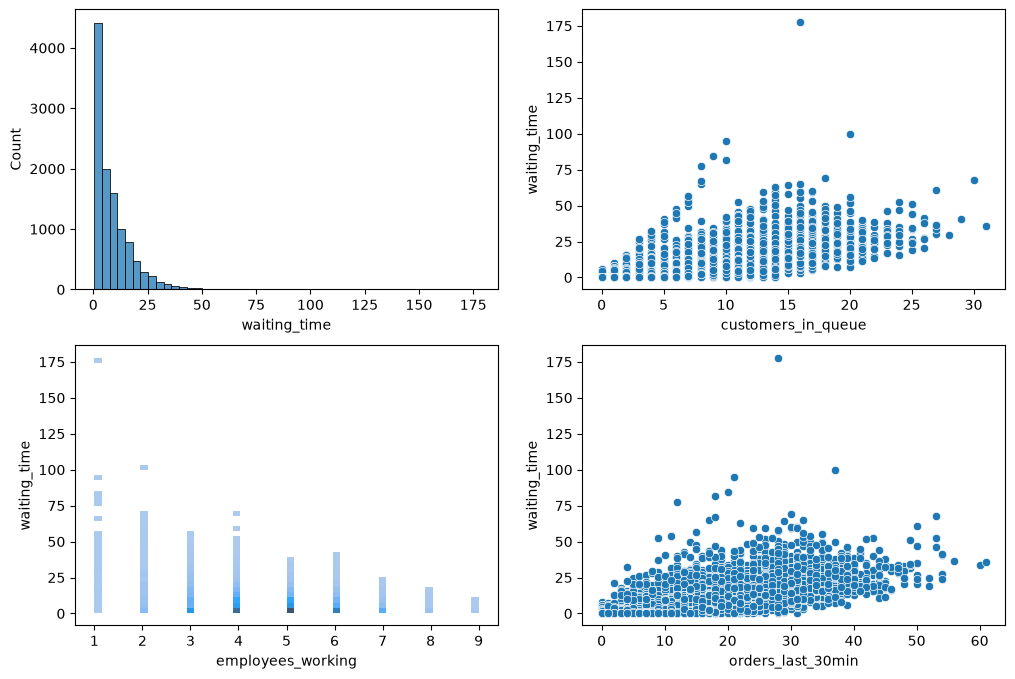

In [108]:
df['timestamp'] = pd.to_datetime(df['timestamp'] ,format='%Y-%m-%d %H:%M:%S')
fig, axes = plt.subplots(2 , 2 , figsize = (12,8))

sns.histplot(data=df , x='waiting_time' , bins=50 , ax=axes[0, 0])
sns.scatterplot(data=df , x='customers_in_queue' , y='waiting_time', ax=axes[0, 1] )
sns.histplot(data=df , x='employees_working' , y='waiting_time',bins=50 , ax=axes[1, 0])
sns.scatterplot(data=df , x='orders_last_30min' , y='waiting_time' , ax=axes[1, 1])

<Axes: xlabel='orders_last_30min', ylabel='waiting_time'>

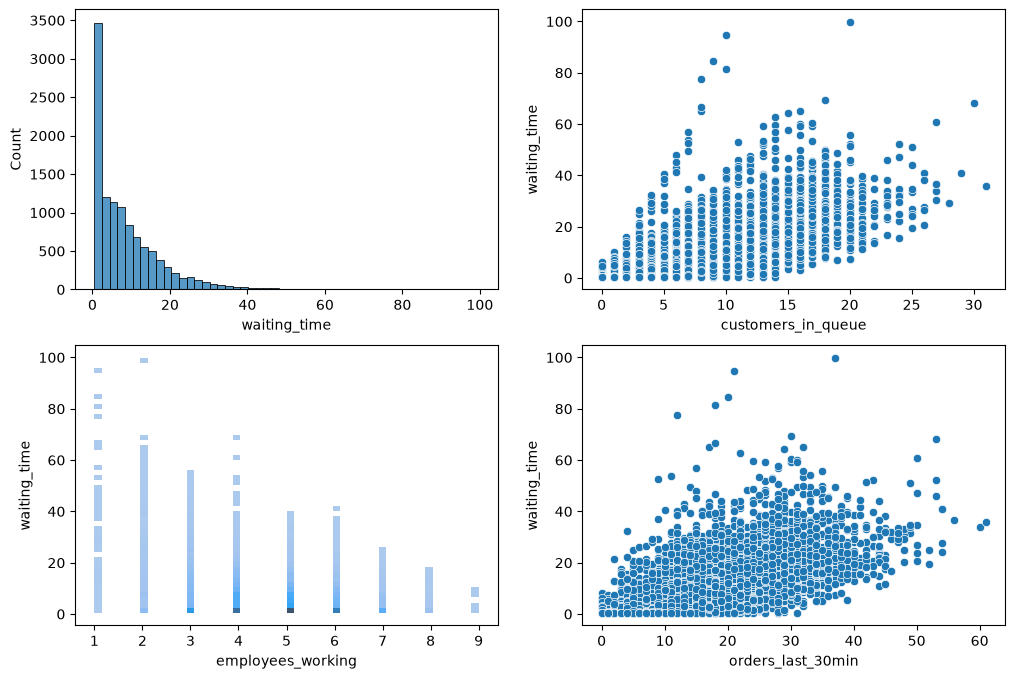

In [109]:
df = df.drop(df['waiting_time'].idxmax())
df['timestamp'] = pd.to_datetime(df['timestamp'] ,format='%Y-%m-%d %H:%M:%S')
fig, axes = plt.subplots(2 , 2 , figsize = (12,8))

sns.histplot(data=df , x='waiting_time' , bins=50 , ax=axes[0, 0])
sns.scatterplot(data=df , x='customers_in_queue' , y='waiting_time', ax=axes[0, 1] )
sns.histplot(data=df , x='employees_working' , y='waiting_time',bins=50 , ax=axes[1, 0])
sns.scatterplot(data=df , x='orders_last_30min' , y='waiting_time' , ax=axes[1, 1])

<Axes: xlabel='avg_service_time', ylabel='waiting_time'>

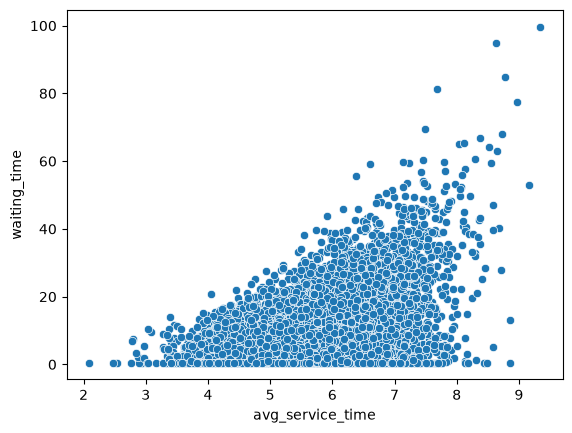

In [110]:
sns.scatterplot(data=df , x='avg_service_time' , y='waiting_time')


<Axes: >

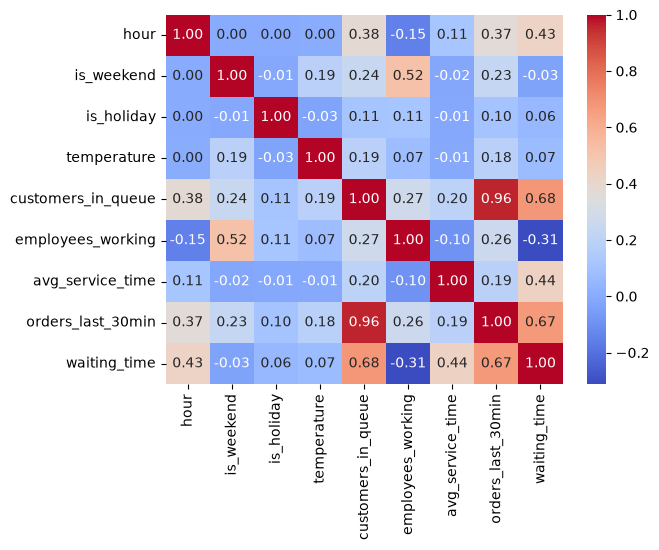

In [111]:
sns.heatmap(data=df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

<Axes: xlabel='hour'>

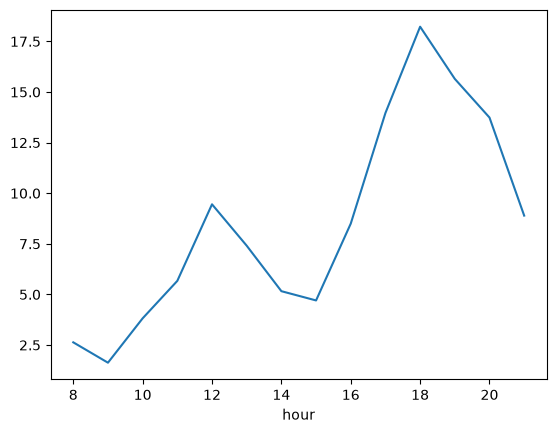

In [112]:
hours_waitting = df.groupby('hour')['waiting_time'].mean()
sns.lineplot(x=hours_waitting.index, y=hours_waitting.values)

<Axes: xlabel='employees_working'>

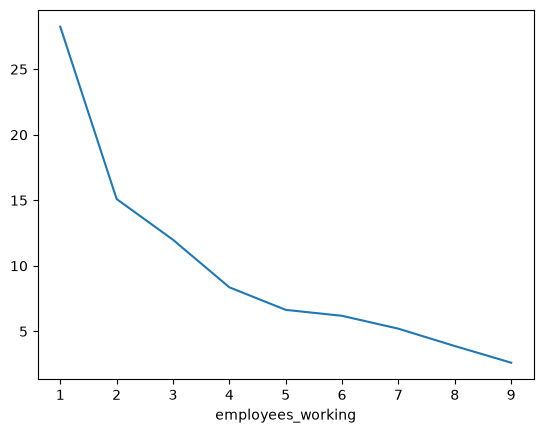

In [113]:
emo_waitting = df.groupby('employees_working')['waiting_time'].mean()
sns.lineplot(x=emo_waitting.index, y=emo_waitting.values)

<Axes: xlabel='day_of_week'>

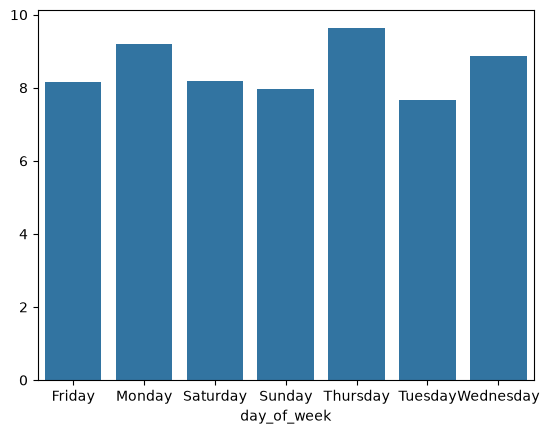

In [114]:
day_of_week_waitting = df.groupby('day_of_week')['waiting_time'].mean()
sns.barplot(x=day_of_week_waitting.index, y=day_of_week_waitting.values)

<Axes: xlabel='is_weekend'>

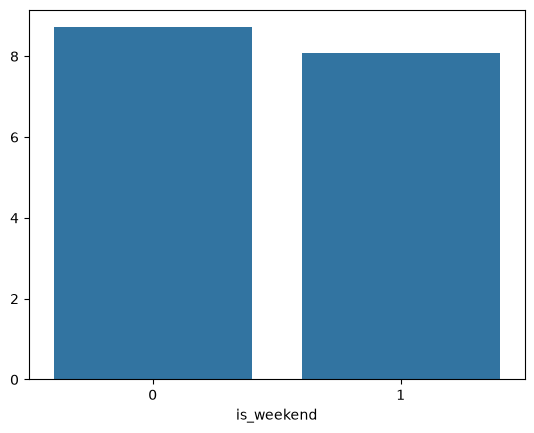

In [115]:
is_weekend_waitting = df.groupby('is_weekend')['waiting_time'].mean()
sns.barplot(x=is_weekend_waitting.index, y=is_weekend_waitting.values)

<Axes: xlabel='is_holiday'>

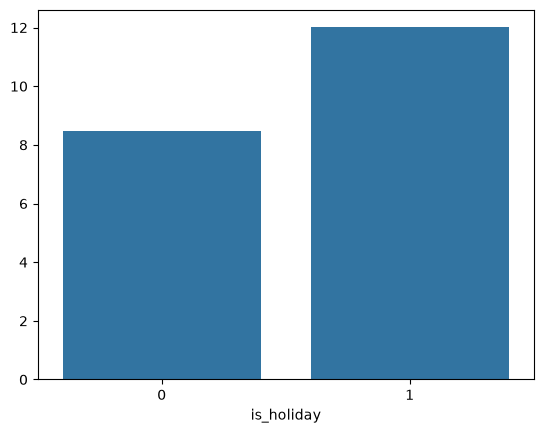

In [116]:
is_holiday_waitting = df.groupby('is_holiday')['waiting_time'].mean()
sns.barplot(x=is_holiday_waitting.index, y=is_holiday_waitting.values)

<Axes: xlabel='weather'>

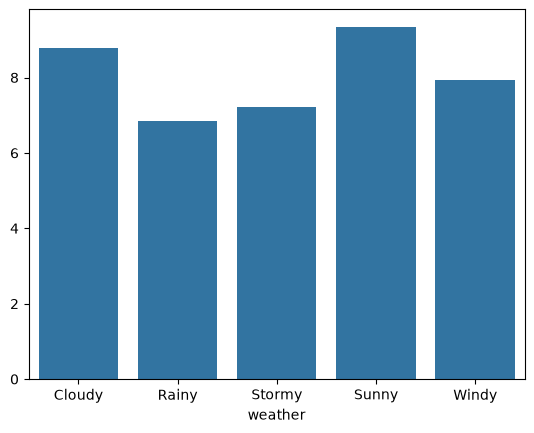

In [117]:
weather_waitting = df.groupby('weather')['waiting_time'].mean()
sns.barplot(x=weather_waitting.index, y=weather_waitting.values)

In [118]:
df.info()

<class 'pandas.DataFrame'>
Index: 11199 entries, 0 to 11199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           11199 non-null  datetime64[us]
 1   day_of_week         11199 non-null  str           
 2   hour                11199 non-null  int64         
 3   is_weekend          11199 non-null  int64         
 4   is_holiday          11199 non-null  int64         
 5   weather             11199 non-null  str           
 6   temperature         11199 non-null  float64       
 7   customers_in_queue  11199 non-null  int64         
 8   employees_working   11199 non-null  int64         
 9   avg_service_time    11199 non-null  float64       
 10  orders_last_30min   11199 non-null  int64         
 11  waiting_time        11199 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(6), str(2)
memory usage: 1.1 MB


In [119]:
import sklearn
from sklearn.preprocessing import StandardScaler , OneHotEncoder  ,PolynomialFeatures
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error , confusion_matrix , r2_score

cat_col = df.select_dtypes(include=['object' , 'str']).columns.tolist()
num_col = df.select_dtypes(include=['number']).columns.tolist()
target = 'waiting_time'
num_col.remove(target)


In [120]:
cat_pipe = Pipeline([
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore' , sparse_output=False))
])
num_pipe = Pipeline([
    ('imputer' , SimpleImputer(strategy='median')),
    ('encoder',StandardScaler())
])
col_prepro = ColumnTransformer([
    ('num' , num_pipe , num_col),
    ('cat' , cat_pipe , cat_col)
])
x_train , x_temp , y_train , y_temp = train_test_split(df[num_col + cat_col] , df[target] , test_size=0.4 , random_state=42)
x_test , x_cv , y_test , y_cv = train_test_split(x_temp, y_temp , test_size=0.5 , random_state=42)

In [121]:
linear_pipe = Pipeline([
    ('preprocessor' , col_prepro),
    ('model' , LinearRegression())
])
linear_pipe.fit(x_train , y_train)
y_train_pred = linear_pipe.predict(x_train)
y_cv_pred = linear_pipe.predict(x_cv)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("CV MAE:", mean_absolute_error(y_cv, y_cv_pred))

print("Train RMSE:", root_mean_squared_error(y_train, y_train_pred))
print("CV RMSE:", root_mean_squared_error(y_cv, y_cv_pred))

print("Train R2:", r2_score(y_train, y_train_pred))
print("CV R2:", r2_score(y_cv, y_cv_pred))

Train MAE: 2.8701641675478604
CV MAE: 2.8145710563912987
Train RMSE: 4.092646974079416
CV RMSE: 3.90894437017489
Train R2: 0.7959782601203131
CV R2: 0.8038177261739163


In [122]:
results_of_ploy = np.zeros((5,6))
for i in range(1,6):
    poly_num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=i, include_bias=False)),
    ('scaler', StandardScaler())
    ])
    poly_preprocessor = ColumnTransformer([
    ('num', poly_num_pipe, num_col),
    ('cat', cat_pipe, cat_col)
    ])
    poly_pipe = Pipeline([
    ('preprocessor', poly_preprocessor),
    ('mode'
    'l', LinearRegression())
    ])

    poly_pipe.fit(x_train , y_train)
    y_train_pred = poly_pipe.predict(x_train)
    y_cv_pred = poly_pipe.predict(x_cv)
    results_of_ploy[i-1,0] = mean_absolute_error(y_train, y_train_pred)
    results_of_ploy[i-1,1] = mean_absolute_error(y_cv, y_cv_pred)
    results_of_ploy[i-1,2] = root_mean_squared_error(y_train, y_train_pred)
    results_of_ploy[i-1,3] = root_mean_squared_error(y_cv, y_cv_pred)
    results_of_ploy[i-1,4] = r2_score(y_train, y_train_pred)
    results_of_ploy[i-1,5] = r2_score(y_cv, y_cv_pred)

results_of_poly = pd.DataFrame(
    results_of_ploy,
    columns=[
        'Train MAE',
        'CV MAE',
        'Train RMSE',
        'CV RMSE',
        'Train R2',
        'CV R2'
    ]
)
results_of_poly.index = range(1, 6)
results_of_poly.index.name = 'Degree'
results_of_poly

,Train MAE,CV MAE,Train RMSE,CV RMSE,Train R2,CV R2
Degree,,,,,,
1,2.870164,2.814571,4.092647,3.908944,0.795978,0.803818
2,1.961681,1.969803,2.639247,2.576525,0.915155,0.914767
3,1.733144,1.764975,2.273251,2.312803,0.937055,0.931322
4,1.615595,1.920949,2.132150,3.236777,0.944626,0.865486
5,1.543304,2.232056,2.043294,5.902827,0.949145,0.552636


In [123]:
results_of_DecTree = np.zeros((6,6))
for i in range(5,11):
    DecTree_pipe = Pipeline([
    ('preprocessor', col_prepro),
    ('model', DecisionTreeRegressor(max_depth=i , random_state=42))
    ])
    DecTree_pipe.fit(x_train , y_train)
    y_train_pred = DecTree_pipe.predict(x_train)
    y_cv_pred = DecTree_pipe.predict(x_cv)
    results_of_DecTree[i-5,0] = mean_absolute_error(y_train, y_train_pred)
    results_of_DecTree[i-5,1] = mean_absolute_error(y_cv, y_cv_pred)
    results_of_DecTree[i-5,2] = root_mean_squared_error(y_train, y_train_pred)
    results_of_DecTree[i-5,3] = root_mean_squared_error(y_cv, y_cv_pred)
    results_of_DecTree[i-5,4] = r2_score(y_train, y_train_pred)
    results_of_DecTree[i-5,5] = r2_score(y_cv, y_cv_pred)

results_of_DecTree = pd.DataFrame(
    results_of_DecTree,
    columns=[
        'Train MAE',
        'CV MAE',
        'Train RMSE',
        'CV RMSE',
        'Train R2',
        'CV R2'
    ]
)
results_of_DecTree.index = range(5, 11)
results_of_DecTree.index.name = 'Max Depth'

results_of_DecTree

,Train MAE,CV MAE,Train RMSE,CV RMSE,Train R2,CV R2
Max Depth,,,,,,
5,2.592572,2.708717,3.581744,3.852143,0.843737,0.809478
6,2.211632,2.365613,3.005400,3.293143,0.889980,0.860761
7,1.953893,2.154494,2.630259,2.951093,0.915732,0.888183
8,1.751771,2.038650,2.347865,2.750479,0.932855,0.902869
9,1.550738,2.025076,2.092465,2.761645,0.946668,0.902079
10,1.337983,2.079711,1.860096,2.844932,0.957856,0.896084


In [124]:
results_of_RanFor = np.zeros((11,6))
for i in range(5,16):
    Random_Forestpipe = Pipeline([
    ('preprocessor', col_prepro),
    ('model', RandomForestRegressor(n_estimators=100,max_depth=i , random_state=42))
    ])
    Random_Forestpipe.fit(x_train , y_train)
    y_train_pred = Random_Forestpipe.predict(x_train)
    y_cv_pred = Random_Forestpipe.predict(x_cv)
    results_of_RanFor[i-5,0] = mean_absolute_error(y_train, y_train_pred)
    results_of_RanFor[i-5,1] = mean_absolute_error(y_cv, y_cv_pred)
    results_of_RanFor[i-5,2] = root_mean_squared_error(y_train, y_train_pred)
    results_of_RanFor[i-5,3] = root_mean_squared_error(y_cv, y_cv_pred)
    results_of_RanFor[i-5,4] = r2_score(y_train, y_train_pred)
    results_of_RanFor[i-5,5] = r2_score(y_cv, y_cv_pred)

results_of_RanFor = pd.DataFrame(
    results_of_RanFor,
    columns=[
        'Train MAE',
        'CV MAE',
        'Train RMSE',
        'CV RMSE',
        'Train R2',
        'CV R2'
    ]
)
results_of_RanFor.index = range(5, 16)
results_of_RanFor.index.name = 'Max Depth'

results_of_RanFor

,Train MAE,CV MAE,Train RMSE,CV RMSE,Train R2,CV R2
Max Depth,,,,,,
5,2.201184,2.272138,2.919984,3.095786,0.896145,0.876950
6,1.959391,2.044134,2.576778,2.755704,0.919124,0.902500
7,1.777206,1.907043,2.324471,2.555180,0.934186,0.916173
8,1.622565,1.834808,2.118310,2.456887,0.945343,0.922498
9,1.470940,1.808323,1.918881,2.427373,0.955150,0.924349
10,1.315531,1.800032,1.718492,2.419767,0.964028,0.924823
11,1.169818,1.805763,1.527418,2.424524,0.971583,0.924527
12,1.040212,1.812906,1.361320,2.430869,0.977427,0.924131
13,0.933097,1.826769,1.228029,2.446385,0.981631,0.923159


In [125]:
neighbors = [1, 3, 5, 7, 10, 15, 20, 30, 40, 50]

results_of_KNN = np.zeros((len(neighbors), 6))

for i, k in enumerate(neighbors):
    KNN_pipe = Pipeline([
        ('preprocessor', col_prepro),
        ('model', KNeighborsRegressor(n_neighbors=k))
    ])
    KNN_pipe.fit(x_train, y_train)
    y_train_pred = KNN_pipe.predict(x_train)
    y_cv_pred = KNN_pipe.predict(x_cv)

    results_of_KNN[i, 0] = mean_absolute_error(y_train, y_train_pred)
    results_of_KNN[i, 1] = mean_absolute_error(y_cv, y_cv_pred)
    results_of_KNN[i, 2] = root_mean_squared_error(y_train, y_train_pred)
    results_of_KNN[i, 3] = root_mean_squared_error(y_cv, y_cv_pred)
    results_of_KNN[i, 4] = r2_score(y_train, y_train_pred)
    results_of_KNN[i, 5] = r2_score(y_cv, y_cv_pred)

results_of_KNN = pd.DataFrame(
    results_of_KNN,
    columns=[
        'Train MAE',
        'CV MAE',
        'Train RMSE',
        'CV RMSE',
        'Train R2',
        'CV R2'
    ]
)
results_of_KNN.index = neighbors
results_of_KNN.index.name = 'Neighbors'

results_of_KNN

,Train MAE,CV MAE,Train RMSE,CV RMSE,Train R2,CV R2
Neighbors,,,,,,
1,0.000000,3.187000,0.000000,4.543693,1.000000,0.734931
3,1.815344,2.606787,2.672602,3.742042,0.912997,0.820213
5,2.033335,2.479721,2.959544,3.587951,0.893312,0.834715
7,2.138601,2.443389,3.112517,3.509568,0.881997,0.841858
10,2.226814,2.433079,3.257533,3.519901,0.870746,0.840925
15,2.325528,2.408185,3.394839,3.487735,0.859620,0.843819
20,2.371202,2.418063,3.475195,3.523373,0.852895,0.840611
30,2.434947,2.472809,3.601828,3.602519,0.841979,0.833370
40,2.487979,2.493259,3.697290,3.639006,0.833492,0.829978


In [167]:
poly_num_pipe = Pipeline([
('imputer', SimpleImputer(strategy='median')),
('poly', PolynomialFeatures(degree=3, include_bias=False)),
('scaler', StandardScaler())
])
poly_preprocessor = ColumnTransformer([
('num', poly_num_pipe, num_col),
('cat', cat_pipe, cat_col)
])
poly_pipe = Pipeline([
('preprocessor', poly_preprocessor),
('model', LinearRegression())
])

poly_pipe.fit(x_train , y_train)
y_test_pred = poly_pipe.predict(x_test)
print("test MAE:", mean_absolute_error(y_test, y_test_pred))

print("test RMSE:", root_mean_squared_error(y_test, y_test_pred))

print("test R2:", r2_score(y_test, y_test_pred))

test MAE: 1.7913213558280852
test RMSE: 2.3450078255891937
test R2: 0.9328038468368014


In [160]:
test_analaysis =[]
test_analaysis = pd.DataFrame(test_analaysis , columns=['Actual' , 'Prediction' , 'Error'])
test_analaysis['Actual'] = y_test
y_test_pred = np.abs(y_test_pred)
test_analaysis['Prediction'] = y_test_pred
test_analaysis['Error'] = np.abs( y_test - y_test_pred )
test_analaysis = test_analaysis.sort_values(by='Error', ascending=False)
test_analaysis

,Actual,Prediction,Error
3133,77.42,63.763707,13.656293
2009,53.69,42.339238,11.350762
7212,34.75,23.504020,11.245980
5822,52.79,43.003418,9.786582
3353,25.27,34.583040,9.313040
...,...,...,...
8347,0.50,0.495577,0.004423
4398,0.50,0.504384,0.004384
10866,0.50,0.496267,0.003733
4022,8.13,8.128798,0.001202


In [161]:
top_10 = test_analaysis.nlargest(10, 'Error')
top_10_features = x_test.loc[top_10.index] 

top_10_full = pd.concat(
    [top_10_features, top_10],
    axis=1
)

top_10_full

,hour,is_weekend,is_holiday,temperature,customers_in_queue,employees_working,avg_service_time,orders_last_30min,day_of_week,weather,Actual,Prediction,Error
3133,21,0,0,18.3,8,1,8.97,12,Tuesday,Stormy,77.42,63.763707,13.656293
2009,20,0,0,18.1,7,1,7.20,11,Wednesday,Rainy,53.69,42.339238,11.350762
7212,19,0,0,22.1,7,2,6.18,15,Friday,Rainy,34.75,23.504020,11.245980
5822,21,0,0,31.4,7,1,7.53,9,Monday,Sunny,52.79,43.003418,9.786582
3353,20,1,0,23.3,14,4,8.40,27,Saturday,Cloudy,25.27,34.583040,9.313040
1430,15,1,0,31.4,9,6,7.17,19,Sunday,Sunny,15.39,7.216179,8.173821
2956,19,1,1,29.4,31,6,5.82,61,Saturday,Sunny,35.99,27.903757,8.086243
603,18,1,0,35.0,16,6,6.13,35,Saturday,Sunny,23.69,15.964836,7.725164
8541,15,0,0,23.8,7,3,4.50,14,Monday,Cloudy,16.35,8.792666,7.557334
4012,17,0,0,20.8,11,5,5.72,24,Thursday,Stormy,18.97,11.432222,7.537778


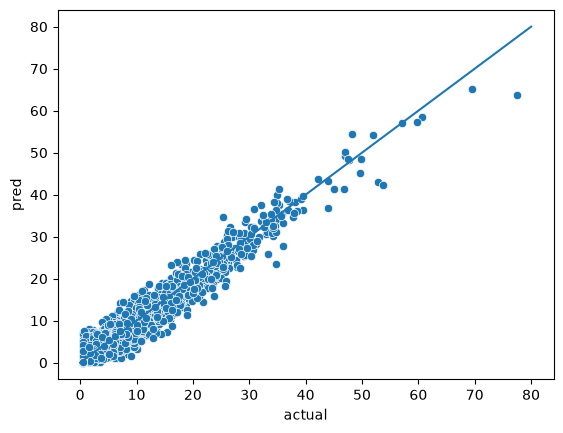

In [166]:
sns.scatterplot(x=y_test , y=y_test_pred)
plt.xlabel('actual')
plt.ylabel('pred')
plt.plot([0, 80], [0, 80])

In [170]:
import joblib
joblib.dump(poly_pipe , 'waiting_time_model.joblib')

['waiting_time_model.joblib']

In [171]:
loaded_model = joblib.load('waiting_time_model.joblib')
new_data = pd.DataFrame([{
    'hour': 18,
    'is_weekend': 0,
    'is_holiday': 0,
    'temperature': 31.5,
    'customers_in_queue': 14,
    'employees_working': 5,
    'avg_service_time': 6.8,
    'orders_last_30min': 22,
    'day_of_week': 'Wednesday',
    'weather': 'Sunny'
}])
pred_load = loaded_model.predict(new_data)
print("Predicted waiting time:", pred_load[0])

Predicted waiting time: 15.522490828338587


In [173]:
from datetime import datetime

now = datetime.now()
now

datetime.datetime(2026, 9, 25, 23, 20, 42, 503500)

In [188]:
import httpx
from datetime import datetime
import os
from dotenv import load_dotenv
load_dotenv()
HOLIDAY_API_KEY = os.getenv("HOLIDAY_API_KEY")
import holidays

now = datetime.now()


us_holidays = holidays.US(years=now.year)

is_holiday = 1 if now.date() in us_holidays else 0

print(is_holiday)

0


In [185]:
import os

print(os.getcwd())
print(os.path.exists(".env"))

/Users/mohammedalasad/Documents/MyPythonProjects/Myproject/TimePred
True
